<a href="https://colab.research.google.com/github/MahsanGhalami/Fundamentals-of-Intelligent-Systems-4041/blob/main/mini3/MINI_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [ ]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

In [ ]:
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

/tmp/ipython-input-165580897.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [ ]:
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipython-input-3985992223.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
df.drop(columns=['Name', 'Ticket', 'Cabin'], inplace=True)

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(['Survived', 'PassengerId'], axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

clf = DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [ ]:
y_pred_train = clf.predict(X_train)
y_pred_test  = clf.predict(X_test)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc  = accuracy_score(y_test, y_pred_test)

In [ ]:
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test  Accuracy: {test_acc:.4f}")

print("Number of nodes:", clf.tree_.node_count)
print("Tree depth:", clf.get_depth())

Train Accuracy: 0.8399
Test  Accuracy: 0.7989
Number of nodes: 29
Tree depth: 4


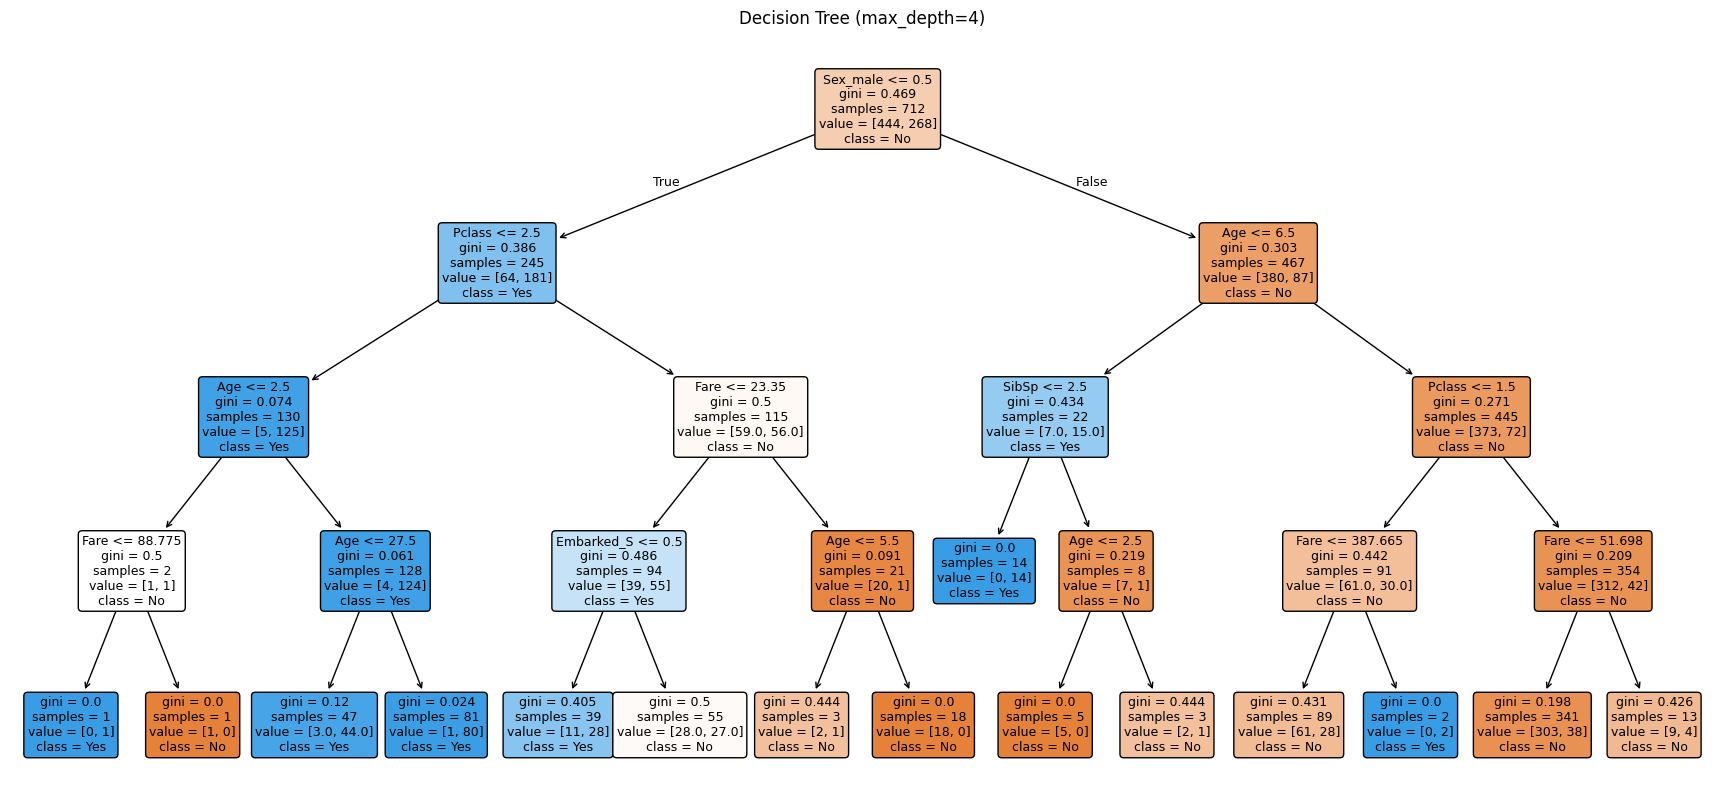

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(22, 10))
plot_tree(
    clf,
    feature_names=list(X_train.columns),
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    impurity=True,
    fontsize=9
)
plt.title("Decision Tree (max_depth=4)")
plt.show()

In [ ]:
feature_importance = pd.Series(
    clf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance)

Sex_male      0.579608
Pclass        0.200498
Fare          0.081064
Age           0.078872
SibSp         0.046059
Embarked_S    0.013900
Parch         0.000000
Embarked_Q    0.000000
dtype: float64


/tmp/ipython-input-3644060897.py:33: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


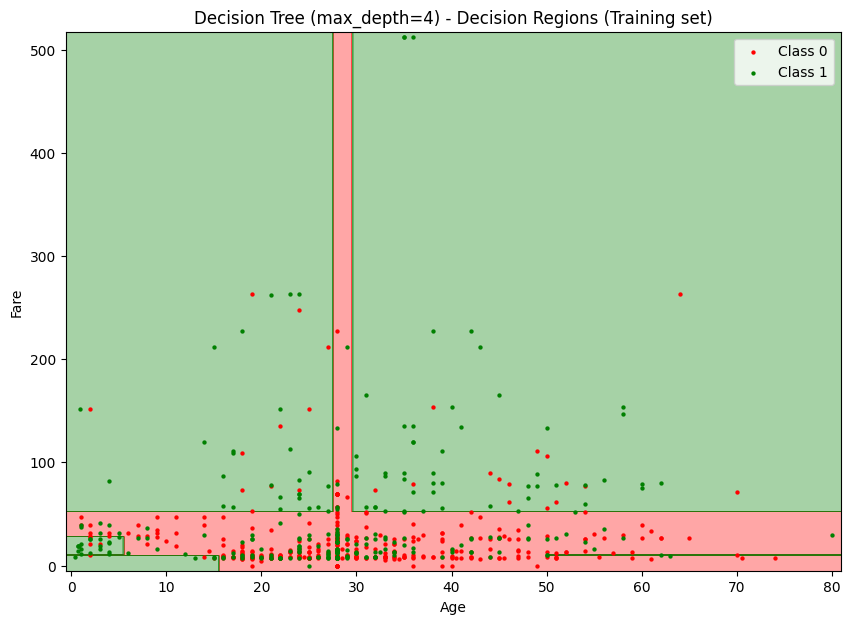

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.tree import DecisionTreeClassifier


X_set = X_train[['Age', 'Fare']].values
y_set = y_train.values

classifier = DecisionTreeClassifier(max_depth=4, random_state=42)
classifier.fit(X_set, y_set)

# meshgrid
X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.25),
    np.arange(start=X_set[:, 1].min() - 5, stop=X_set[:, 1].max() + 5, step=0.25)
)


plt.figure(figsize=(10, 7))
plt.contourf(
    X1, X2,
    classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.35,
    cmap=ListedColormap(("red", "green"))
)

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

# training set
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],
        c=ListedColormap(("red", "green"))(i),
        label=f"Class {j}",
        s=18,
        marker="."
    )

plt.title("Decision Tree (max_depth=4) - Decision Regions (Training set)")
plt.xlabel('Age')
plt.ylabel('Fare')
plt.legend()
plt.show()

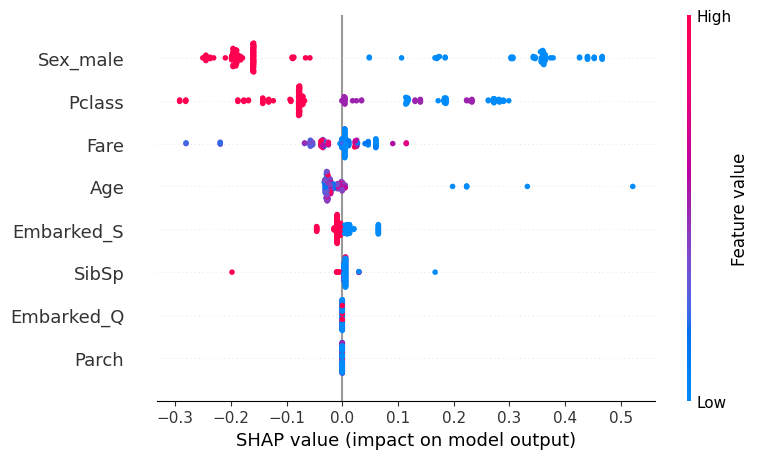

In [ ]:
import shap
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)
# for class 1
shap.summary_plot(shap_values[:, :, 1], X_test,max_display=X_test.shape[1])

##**Q6**

آموزش درخت کامل)بدون محدودیت عمق

In [ ]:
clf_full = DecisionTreeClassifier(max_depth=None, random_state=42)
clf_full.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred_train_full = clf_full.predict(X_train)
y_pred_test_full  = clf_full.predict(X_test)

train_acc_full = accuracy_score(y_train, y_pred_train_full)
test_acc_full  = accuracy_score(y_test, y_pred_test_full)

print(f"Train Accuracy (full tree): {train_acc_full:.4f}")
print(f"Test  Accuracy (full tree): {test_acc_full:.4f}")

print("Number of nodes (full tree):", clf_full.tree_.node_count)
print("Tree depth (full tree):", clf_full.get_depth())

Train Accuracy (full tree): 0.9789
Test  Accuracy (full tree): 0.7821
Number of nodes (full tree): 359
Tree depth (full tree): 21


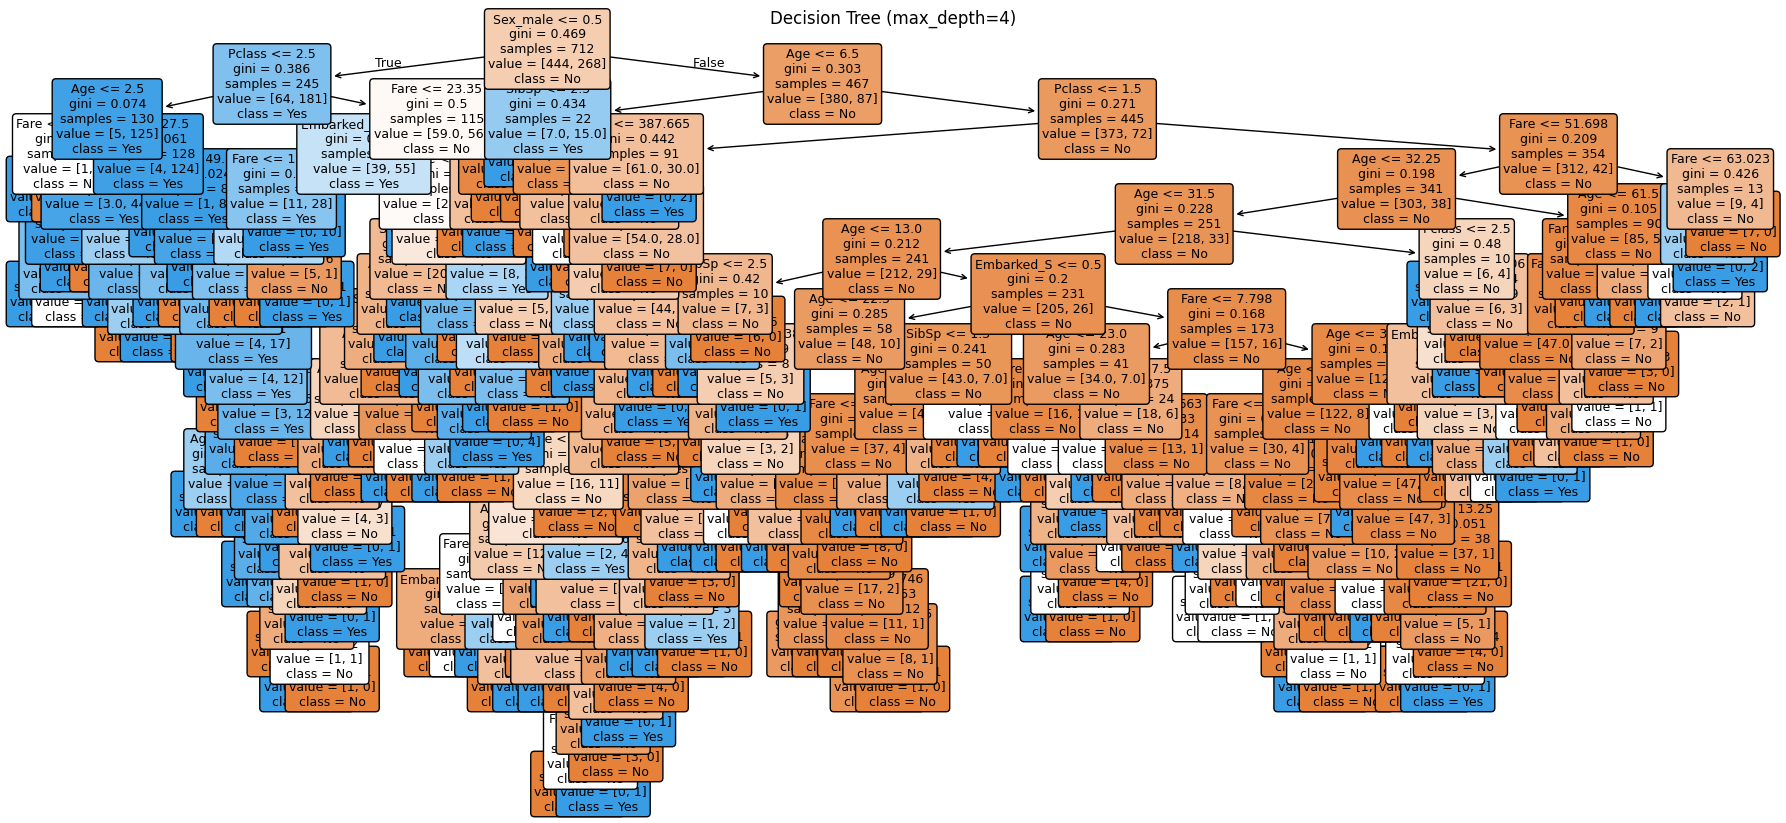

In [ ]:
plt.figure(figsize=(22, 10))
plot_tree(
    clf_full,
    feature_names=list(X_train.columns),
    class_names=["No", "Yes"],
    filled=True,
    rounded=True,
    impurity=True,
    fontsize=9
)
plt.title("Decision Tree (max_depth=4)")
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

depths = [3,5,10,None]
train_accuracies = []
test_accuracies = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)

    y_train_pred = clf.predict(X_train)
    y_test_pred  = clf.predict(X_test)

    train_accuracies.append(accuracy_score(y_train, y_train_pred))
    test_accuracies.append(accuracy_score(y_test, y_test_pred))

    print(f"max_depth = {d}")
    print(f"  Train Accuracy: {train_accuracies[-1]:.4f}")
    print(f"  Test  Accuracy: {test_accuracies[-1]:.4f}")

max_depth = 3
  Train Accuracy: 0.8343
  Test  Accuracy: 0.7989
max_depth = 5
  Train Accuracy: 0.8511
  Test  Accuracy: 0.7989
max_depth = 10
  Train Accuracy: 0.9129
  Test  Accuracy: 0.7933
max_depth = None
  Train Accuracy: 0.9789
  Test  Accuracy: 0.7821


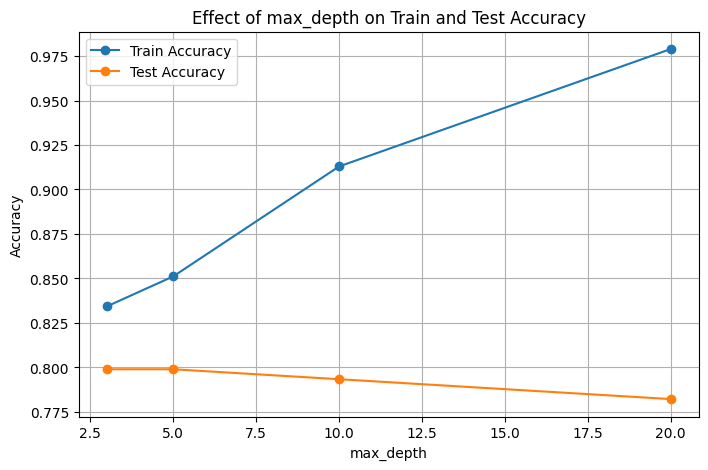

In [ ]:
plot_depths = [3,5,10,20]

plt.figure(figsize=(8, 5))
plt.plot(plot_depths, train_accuracies, marker='o', label='Train Accuracy')
plt.plot(plot_depths, test_accuracies, marker='o', label='Test Accuracy')

plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Effect of max_depth on Train and Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()

 Train full tree (ccp_alpha=0) to get pruning path

In [ ]:
full_clf = DecisionTreeClassifier(random_state=42)
full_clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

 Get ccp_alpha path

In [ ]:
path = full_clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# keep only positive alphas (remove 0)
ccp_alphas = ccp_alphas[ccp_alphas > 0]

print("\nNumber of positive alphas:", len(ccp_alphas))
print("First 10 alphas:", ccp_alphas[:10])


Number of positive alphas: 68
First 10 alphas: [3.90137328e-05 6.29695337e-05 6.68806849e-05 7.29607471e-05
 1.30448395e-04 2.34082397e-04 2.34082397e-04 3.51123596e-04
 4.27454812e-04 4.68164794e-04]


Train a tree for each positive alpha + compute metrics

In [ ]:
rows = []
for a in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=a)
    clf.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc  = accuracy_score(y_test,  clf.predict(X_test))

    rows.append({
        "ccp_alpha": a,
        "train_acc": train_acc,
        "test_acc": test_acc,
        "nodes": clf.tree_.node_count,
        "depth": clf.get_depth()
    })

results = pd.DataFrame(rows)
results.head()

,ccp_alpha,train_acc,test_acc,nodes,depth
0,0.000039,0.978933,0.782123,355,21
1,0.000063,0.978933,0.782123,349,21
2,0.000067,0.978933,0.782123,347,21
3,0.000073,0.978933,0.782123,343,21
4,0.000130,0.978933,0.782123,339,21


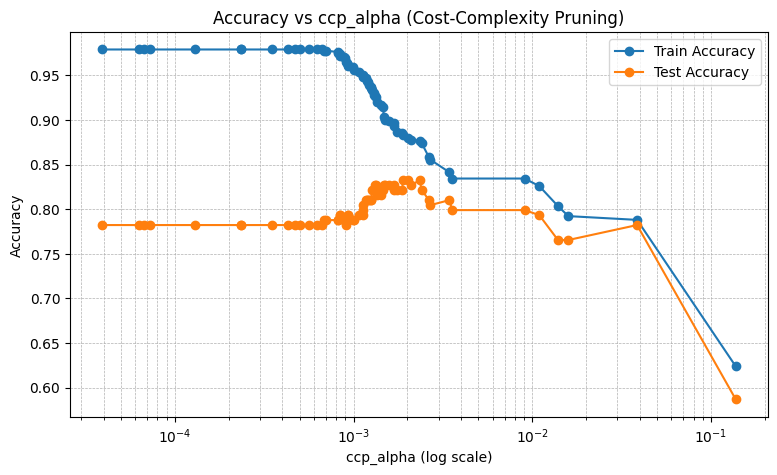

In [ ]:
plt.figure(figsize=(9,5))
plt.plot(results["ccp_alpha"], results["train_acc"], marker="o", label="Train Accuracy")
plt.plot(results["ccp_alpha"], results["test_acc"],  marker="o", label="Test Accuracy")
plt.xscale("log")
plt.xlabel("ccp_alpha (log scale)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs ccp_alpha (Cost-Complexity Pruning)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()

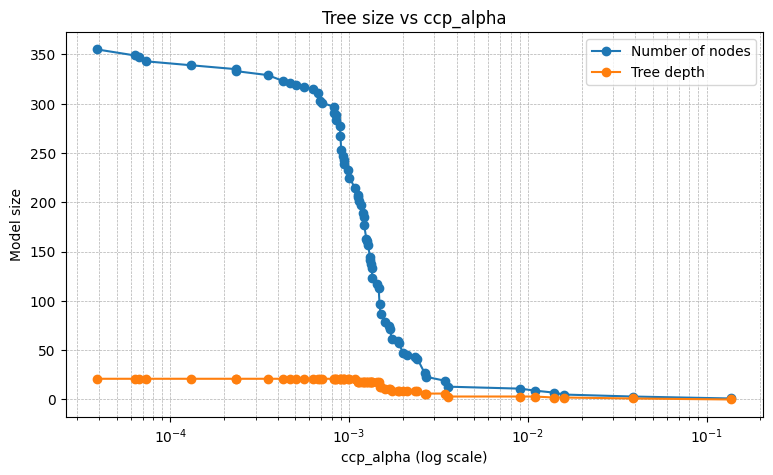

In [ ]:
plt.figure(figsize=(9,5))
plt.plot(results["ccp_alpha"], results["nodes"], marker="o", label="Number of nodes")
plt.plot(results["ccp_alpha"], results["depth"], marker="o", label="Tree depth")
plt.xscale("log")
plt.xlabel("ccp_alpha (log scale)")
plt.ylabel("Model size")
plt.title("Tree size vs ccp_alpha")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.legend()
plt.show()

Automatic alpha selection based on constraints

In [ ]:
full_nodes = clf_full.tree_.node_count
full_depth = clf_full.get_depth()
full_test_acc = test_acc_full

max_test_drop = 0.005
min_node_reduction = 0.30
min_depth_reduction = 0.20

results["node_reduction"]  = (full_nodes - results["nodes"]) / full_nodes
results["depth_reduction"] = (full_depth - results["depth"]) / full_depth
results["test_drop"]       = full_test_acc - results["test_acc"]

candidates = results[
    (results["test_drop"] <= max_test_drop) &
    (results["node_reduction"] >= min_node_reduction) &
    (results["depth_reduction"] >= min_depth_reduction)
].copy()

print("Number of Candidates found:", len(candidates))

chosen = candidates.sort_values("ccp_alpha").iloc[0]
print("\nCHOSEN MODEL")
print(chosen[["ccp_alpha","train_acc","test_acc","nodes","depth","node_reduction","depth_reduction","test_drop"]])

Number of Candidates found: 19

CHOSEN MODEL
ccp_alpha           0.001479
train_acc           0.903090
test_acc            0.826816
nodes              97.000000
depth              13.000000
node_reduction      0.729805
depth_reduction     0.380952
test_drop          -0.044693
Name: 46, dtype: float64


In [ ]:
def eval_tree(model_name, clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc  = accuracy_score(y_test,  clf.predict(X_test))
    nodes = clf.tree_.node_count
    depth = clf.get_depth()
    return {
        "Model": model_name,
        "Train Acc": train_acc,
        "Test Acc": test_acc,
        "Gap (Train-Test)": train_acc - test_acc,
        "Nodes": nodes,
        "Depth": depth
    }

In [ ]:
# -------------------------------
# 1) shallow tree (max_depth=4)
# -------------------------------
clf_shallow = DecisionTreeClassifier(max_depth=4, random_state=42)

# -------------------------------
# 2) full tree (no pruning)
# -------------------------------
clf_full = DecisionTreeClassifier(random_state=42)

# -------------------------------
# 3) pruned tree (chosen alpha)
# -------------------------------
alpha_star = 0.001479
clf_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha_star)

rows = []
rows.append(eval_tree("Shallow Tree (max_depth=4)", clf_shallow, X_train, y_train, X_test, y_test))
rows.append(eval_tree("Full Tree (no pruning)", clf_full, X_train, y_train, X_test, y_test))
rows.append(eval_tree(f"Pruned Tree (ccp_alpha={alpha_star})", clf_pruned, X_train, y_train, X_test, y_test))

df_models = pd.DataFrame(rows)


full_nodes = df_models.loc[df_models["Model"].str.contains("Full Tree"), "Nodes"].values[0]
full_depth = df_models.loc[df_models["Model"].str.contains("Full Tree"), "Depth"].values[0]

df_models["Node Reduction vs Full"] = (full_nodes - df_models["Nodes"]) / full_nodes
df_models["Depth Reduction vs Full"] = (full_depth - df_models["Depth"]) / full_depth

df_models

,Model,Train Acc,Test Acc,Gap (Train-Test),Nodes,Depth,Node Reduction vs Full,Depth Reduction vs Full
0,Shallow Tree (max_depth=4),0.839888,0.798883,0.041005,29,4,0.919220,0.809524
1,Full Tree (no pruning),0.978933,0.782123,0.196810,359,21,0.000000,0.000000
2,Pruned Tree (ccp_alpha=0.001479),0.914326,0.821229,0.093097,113,18,0.685237,0.142857


##Q12

Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200,random_state=42)
rf.fit(X_train, y_train)
y_train_pred = rf.predict(X_train)
y_test_pred = rf.predict(X_test)
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Random Forest (n_estimators=200)")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Accuracy Gap (Train - Test): {train_acc - test_acc:.4f}")

Random Forest (n_estimators=200)
Train Accuracy: 0.9789
Test Accuracy:  0.8101
Accuracy Gap (Train - Test): 0.1689


GradientBoostingClassifier

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(n_estimators=200,learning_rate=0.05,random_state=42)
gb.fit(X_train, y_train)

y_train_pred = gb.predict(X_train)
y_test_pred = gb.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print("GradientBoostingClassifier")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Accuracy Gap (Train - Test): {train_acc - test_acc:.4f}")

GradientBoostingClassifier
Train Accuracy: 0.8989
Test Accuracy:  0.8101
Accuracy Gap (Train - Test): 0.0888
